# Autoencoder

An **Autoencoder** is an unsupervised neural network that learns to compress data into a lower-dimensional *latent (bottleneck) representation* and then reconstruct it.

$$
\mathcal{L}_{\text{recon}} = \frac{1}{n}\sum_{i=1}^{n}\|\mathbf{x}_i - \hat{\mathbf{x}}_i\|^2
$$

## Architecture

$$
\underbrace{\mathbf{x}}_{\text{input}} \xrightarrow{\text{Encoder}} \underbrace{\mathbf{z}}_{\text{bottleneck}} \xrightarrow{\text{Decoder}} \underbrace{\hat{\mathbf{x}}}_{\text{reconstruction}}
$$

- **Encoder**: maps $\mathbf{x} \in \mathbb{R}^d \to \mathbf{z} \in \mathbb{R}^k$, $k \ll d$
- **Decoder**: maps $\mathbf{z} \to \hat{\mathbf{x}}$ (mirrored architecture)
- **Loss**: MSE reconstruction loss + optional L2 regularisation


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('../../src')))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_digits
from sklearn.preprocessing import MinMaxScaler

from rice_ml.unsupervised_learning.autoencoder import Autoencoder

np.random.seed(42)


## 1. Iris dataset — 4D → 2D compression

In [2]:
iris = load_iris()
X_iris = MinMaxScaler().fit_transform(iris.data)

ae = Autoencoder(encoding_dims=[3, 2], activation='relu',
                 learning_rate=1e-2, n_iterations=300,
                 batch_size=16, random_state=42, verbose=False)
ae.fit(X_iris)

Z = ae.transform(X_iris)
print(f"Original shape : {X_iris.shape}")
print(f"Encoded shape  : {Z.shape}")
print(f"Reconstruction MSE: {ae.reconstruction_loss(X_iris):.5f}")


Original shape : (150, 4)
Encoded shape  : (150, 2)
Reconstruction MSE: 0.06861


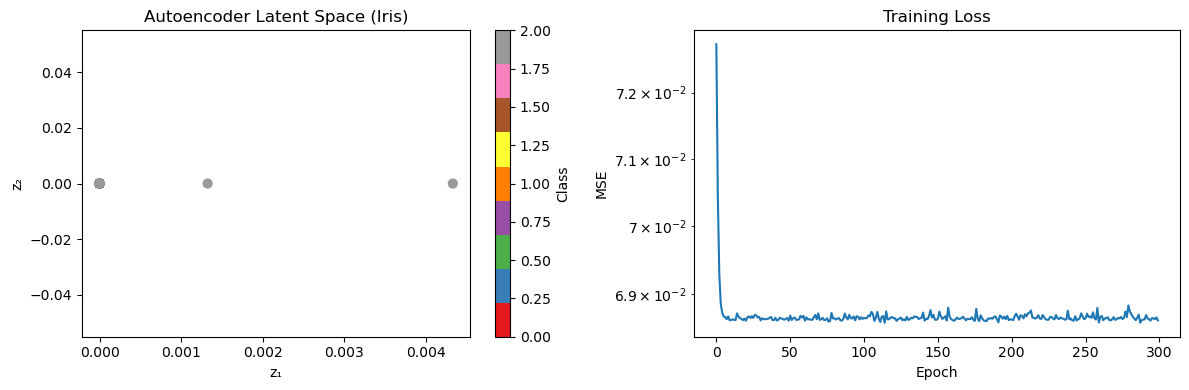

Plot saved.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Latent space
sc = axes[0].scatter(Z[:, 0], Z[:, 1], c=iris.target, cmap='Set1', s=40)
axes[0].set_title('Autoencoder Latent Space (Iris)')
axes[0].set_xlabel('z₁'); axes[0].set_ylabel('z₂')
plt.colorbar(sc, ax=axes[0], label='Class')

# Training loss
axes[1].plot(ae.loss_history_)
axes[1].set_title('Training Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('ae_iris.png', dpi=80)
plt.show()
print("Plot saved.")


## 2. Digits dataset — anomaly detection demo

In [4]:
digits = load_digits()
X_dig = MinMaxScaler().fit_transform(digits.data)

# Train on digits 0-7 only, detect 8-9 as anomalies
mask_train = digits.target < 8
X_train = X_dig[mask_train]
X_all   = X_dig

ae_dig = Autoencoder(encoding_dims=[32, 16], activation='relu',
                     learning_rate=5e-3, n_iterations=200,
                     batch_size=32, random_state=0, verbose=False)
ae_dig.fit(X_train)

errors = np.mean((ae_dig.reconstruct(X_all) - X_all) ** 2, axis=1)
labels = np.where(digits.target >= 8, 'Anomaly (8-9)', 'Normal (0-7)')

print(f"Mean error (normal): {errors[mask_train].mean():.4f}")
print(f"Mean error (anomaly): {errors[~mask_train].mean():.4f}")


Mean error (normal): 0.0081
Mean error (anomaly): 0.0211


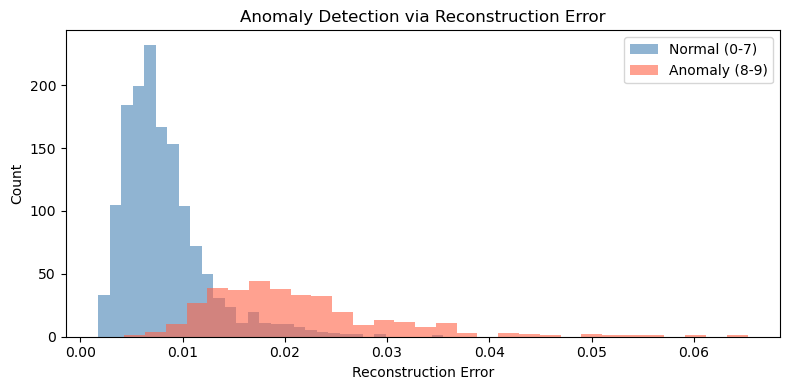

In [5]:
plt.figure(figsize=(8, 4))
plt.hist(errors[mask_train], bins=30, alpha=0.6, label='Normal (0-7)', color='steelblue')
plt.hist(errors[~mask_train], bins=30, alpha=0.6, label='Anomaly (8-9)', color='tomato')
plt.xlabel('Reconstruction Error'); plt.ylabel('Count')
plt.title('Anomaly Detection via Reconstruction Error')
plt.legend()
plt.tight_layout()
plt.savefig('ae_anomaly.png', dpi=80)
plt.show()


## 3. Reconstruction visualisation


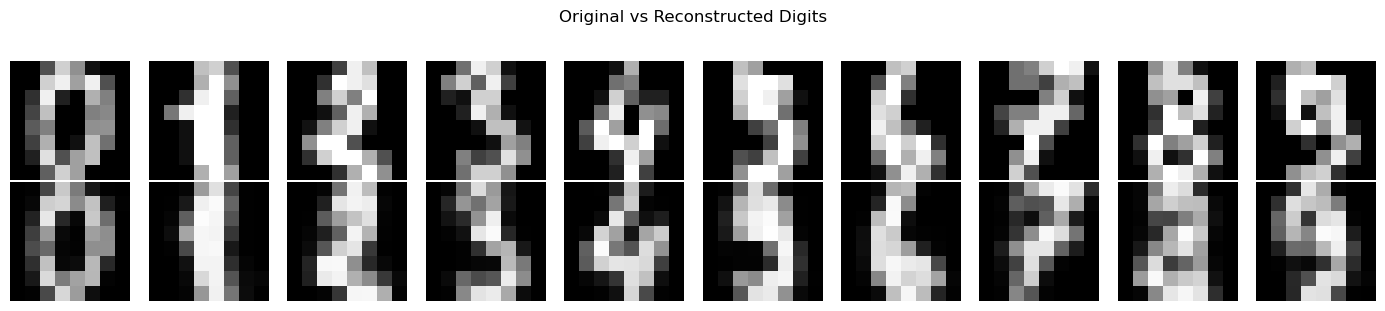

In [6]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
X_sample = X_dig[:10]
X_recon  = ae_dig.reconstruct(X_sample)

for i in range(10):
    axes[0, i].imshow(X_sample[i].reshape(8, 8), cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[1, i].imshow(X_recon[i].reshape(8, 8), cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=10)
axes[1, 0].set_ylabel('Recon', fontsize=10)
plt.suptitle('Original vs Reconstructed Digits', y=1.02)
plt.tight_layout()
plt.savefig('ae_recon.png', dpi=80)
plt.show()


## Model Limitations

| Limitation | Detail |
|---|---|
| Linear bottleneck | If no non-linear activation is used, AE reduces to PCA |
| No latent space regularisation | Unlike VAEs, encodings can be discontinuous |
| MSE prefers blurry reconstructions | Alternative losses (perceptual, BCE) can help |
| Sensitive to architecture | Bottleneck dimension must be tuned |
| No generative capability | Cannot sample new data points (use VAE/GAN instead) |
